# Loading Data and Dividing CSV file into Parquet Files

In [15]:
import pandas as pd
import logging
import sys
import os

# Setting up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filename='/content/loading.log'
)
logger = logging.getLogger(__name__)

# Loading the Dataset
try:
    logger.info("Loading dataset...")
    df = pd.read_csv("/content/Features_For_Traditional_ML_Techniques.csv")
    logger.info(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    logger.error("Dataset file not found")
    sys.exit(1)
except Exception as e:
    logger.error(f"Unexpected error loading dataset: {e}")
    sys.exit(1)

# Dropping Irrelevant Columns and creating Unique Identifier for PK
try:
    df = df.drop(columns=['Unnamed: 0'])
    df['tweet_ID'] = df.index + 1
    logger.info("Dropped 'Unnamed: 0' and created tweet_ID")
except KeyError:
    logger.warning("'Unnamed: 0' column not found — skipping drop")
    df['tweet_ID'] = df.index + 1
except Exception as e:
    logger.error(f"Error during column setup: {e}")
    sys.exit(1)

# Creating text dataframe
try:
    text = df[[
        'tweet_ID', 'unique_count', 'total_count', 'ORG_percentage', 'NORP_percentage',
        'GPE_percentage', 'PERSON_percentage', 'MONEY_percentage', 'DATE_percentage',
        'CARDINAL_percentage', 'PERCENT_percentage', 'ORDINAL_percentage', 'LAW_percentage',
        'PRODUCT_percentage', 'EVENT_percentage', 'TIME_percentage', 'LOC_percentage',
        'WORK_OF_ART_percentage', 'QUANTITY_percentage', 'LANGUAGE_percentage',
        'Max word length', 'Min word length', 'Average word length'
    ]]
    logger.info("Text table created")

# Creating lexical dataframe
    lexical = df[[
        'tweet_ID', 'present_verbs', 'past_verbs', 'adjectives', 'pronouns', 'TOs',
        'determiners', 'conjunctions', 'dots', 'exclamation', 'questions', 'ampersand',
        'capitals', 'quotes', 'digits', 'long_word_freq', 'short_word_freq'
    ]]
    logger.info("Lexical table created")

# Creating metadata dataframe
    metadata = df[[
        'tweet_ID', 'followers_count', 'friends_count', 'favourites_count',
        'statuses_count', 'listed_count', 'mentions', 'quotes', 'replies',
        'retweets', 'favourites', 'hashtags', 'URLs'
    ]]
    logger.info("Metadata table created")

# Creating scores dataframe
    scores = df[[
        'tweet_ID', 'BotScoreBinary', 'normalize_influence', 'BinaryNumTarget', 'cred'
    ]]
    logger.info("Scores table created")

except SystemExit:
    raise
except Exception as e:
    logger.error(f"Unexpected error creating feature tables: {e}")
    sys.exit(1)

# Saving to parquet files
for name, table in [('text', text), ('lexical', lexical), ('metadata', metadata), ('scores', scores)]:
    try:
        path = f'/content/{name}.parquet'
        table.to_parquet(path, index=False)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Parquet file was not created at {path}")
        logger.info(f"Saved {name}.parquet — {table.shape[0]} rows, {table.shape[1]} cols")
    except Exception as e:
        logger.error(f"Failed to save {name}.parquet: {e}")
        sys.exit(1)

logger.info("Done")

# Creating DuckDB Connection and Initializing Tables

In [16]:
import duckdb
import logging
import sys
import os

logger = logging.getLogger(__name__)

# Checking for parquet files
parquet_files = ['text', 'lexical', 'metadata', 'scores']
for name in parquet_files:
    path = f'/content/{name}.parquet'
    if not os.path.exists(path):
        logger.error(f"Missing parquet file: {path}")
        sys.exit(1)

# Creating DuckDB Connection
try:
    con = duckdb.connect()
    logger.info("DuckDB connection established")
except Exception as e:
    logger.error(f"Failed to create DuckDB connection: {e}")
    sys.exit(1)

# Initializing Tables
for name in parquet_files:
    try:
        path = f'/content/{name}.parquet'
        con.execute(f"CREATE TABLE {name} AS SELECT * FROM read_parquet('{path}')")
        row_count = con.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
        logger.info(f"Table '{name}' loaded — {row_count} rows")
    except duckdb.IOException as e:
        logger.error(f"Could not read {name}.parquet: {e}")
        sys.exit(1)
    except duckdb.CatalogException as e:
        logger.error(f"Table '{name}' already exists: {e}")
        sys.exit(1)
    except Exception as e:
        logger.error(f"Unexpected error loading table '{name}': {e}")
        sys.exit(1)

logger.info("All tables loaded into DuckDB successfully!")

## Queries

In [17]:
# Query exploring how many tweets were posted by bots
con.execute("""
    SELECT BotScoreBinary, COUNT(*) as count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage
    FROM scores
    GROUP BY BotScoreBinary
""").df()

,BotScoreBinary,count,percentage
0,0.0,129856,96.76
1,1.0,4342,3.24


In [18]:
# Query exploring how many tweets were deemed fake or true
con.execute("""
    SELECT BinaryNumTarget, COUNT(*) as count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage
    FROM scores
    GROUP BY BinaryNumTarget
""").df()

,BinaryNumTarget,count,percentage
0,0.0,65268,48.64
1,1.0,68930,51.36


In [19]:
# Query looking at average of lexical features per binary bot distinction
con.execute("""
    SELECT s.BotScoreBinary,
           AVG(l.present_verbs) as avg_present_verbs,
           AVG(l.capitals) as avg_capitals,
           AVG(l.exclamation) as avg_exclamations,
           AVG(l.questions) as avg_question,
           AVG(m.hashtags) as avg_hashtags,
           AVG(m.retweets) as avg_retweets
    FROM lexical l
    JOIN metadata m ON l.tweet_id = m.tweet_ID
    JOIN scores s ON l.tweet_id = s.tweet_ID
    GROUP BY s.BotScoreBinary
""").df()

,BotScoreBinary,avg_present_verbs,avg_capitals,avg_exclamations,avg_question,avg_hashtags,avg_retweets
0,0.0,2.452517,12.825306,0.259095,0.307410,0.104624,6.893698
1,1.0,2.447490,13.029249,0.268770,0.299401,0.107784,0.114463


In [20]:
# Query looking at average of lexical features per binary news distinction
con.execute("""
    SELECT s.BinaryNumTarget,
           AVG(l.present_verbs) as avg_present_verbs,
           AVG(l.capitals) as avg_capitals,
           AVG(l.exclamation) as avg_exclamations,
           AVG(l.questions) as avg_question,
           AVG(m.hashtags) as avg_hashtags,
           AVG(m.retweets) as avg_retweets
    FROM lexical l
    JOIN metadata m ON l.tweet_id = m.tweet_ID
    JOIN scores s ON l.tweet_id = s.tweet_ID
    GROUP BY s.BinaryNumTarget
""").df()

,BinaryNumTarget,avg_present_verbs,avg_capitals,avg_exclamations,avg_question,avg_hashtags,avg_retweets
0,0.0,2.646274,14.139502,0.322578,0.342358,0.054897,7.857618
1,1.0,2.268736,11.593776,0.199594,0.273814,0.151908,5.553953


In [21]:
# Query looking at the average of scores based on binary bot distinction
con.execute("""
    SELECT s.BotScoreBinary,
           AVG(cred) as avg_credibility,
           AVG(normalize_influence) as avg_influence,
           SUM(s.BinaryNumTarget) as truenews_count,
           COUNT(*) as total
    FROM scores s
    JOIN text t ON s.tweet_ID = t.tweet_ID
    GROUP BY s.BotScoreBinary
""").df()

,BotScoreBinary,avg_credibility,avg_influence,truenews_count,total
0,0.0,0.411076,0.079339,66853.0,129856
1,1.0,0.249599,0.027578,2077.0,4342


In [22]:
# Query looking at the average of scores based on binary news distinction
con.execute("""
    SELECT s.BinaryNumTarget,
           AVG(cred) as avg_credibility,
           AVG(normalize_influence) as avg_influence,
           SUM(s.BotScoreBinary) as bots,
           COUNT(*) as total
    FROM scores s
    JOIN text t ON s.tweet_ID = t.tweet_ID
    GROUP BY s.BinaryNumTarget
""").df()

,BinaryNumTarget,avg_credibility,avg_influence,bots,total
0,1.0,0.431826,0.081024,2077.0,68930
1,0.0,0.378420,0.074116,2265.0,65268


In [23]:
# Querying correlation of Binary Bot Score with Lexical features and Real/Fake binary target
con.execute("""
    SELECT
        CORR(capitals, s.BotScoreBinary) as capitals_corr,
        CORR(exclamation, s.BotScoreBinary) as exclamations_corr,
        CORR(retweets, s.BotScoreBinary) as retweets_corr,
        CORR(cred, s.BotScoreBinary) as cred_corr,
        CORR(s.BinaryNumTarget, s.BotScoreBinary) as truefake_corr,
        CORR(followers_count, s.BotScoreBinary) as followers_corr
    FROM lexical l
    JOIN metadata m ON l.tweet_id = m.tweet_ID
    JOIN scores s ON l.tweet_id = s.tweet_ID
    JOIN text t ON l.tweet_id = t.tweet_ID
""").df()

,capitals_corr,exclamations_corr,retweets_corr,cred_corr,truefake_corr,followers_corr
0,0.00232,0.001894,-0.002951,-0.119437,-0.012912,-0.004687


In [24]:
# Querying correlation of True/Fake Values with Lexical features and bot binary value
con.execute("""
    SELECT
        CORR(capitals, s.BinaryNumTarget) as capitals_corr,
        CORR(exclamation, s.BinaryNumTarget) as exclamations_corr,
        CORR(retweets, s.BinaryNumTarget) as retweets_corr,
        CORR(cred, s.BinaryNumTarget) as cred_corr,
        CORR(s.BotScoreBinary, s.BinaryNumTarget) as bot_corr,
        CORR(followers_count, s.BinaryNumTarget) as followers_corr
    FROM lexical l
    JOIN metadata m ON l.tweet_id = m.tweet_ID
    JOIN scores s ON l.tweet_id = s.tweet_ID
    JOIN text t ON l.tweet_id = t.tweet_ID
""").df()

,capitals_corr,exclamations_corr,retweets_corr,cred_corr,bot_corr,followers_corr
0,-0.081786,-0.068,-0.002832,0.111584,-0.012912,0.013712


# Random Forest Implementation


── Fake News Detection Results ──
              precision    recall  f1-score   support

         0.0       0.67      0.70      0.69     13054
         1.0       0.71      0.68      0.69     13786

    accuracy                           0.69     26840
   macro avg       0.69      0.69      0.69     26840
weighted avg       0.69      0.69      0.69     26840

[[9183 3871]
 [4428 9358]]

── Bot Detection Results ──
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     25972
         1.0       0.98      0.93      0.95       868

    accuracy                           1.00     26840
   macro avg       0.99      0.97      0.98     26840
weighted avg       1.00      1.00      1.00     26840

[[25953    19]
 [   60   808]]


/tmp/ipykernel_1382/3993341904.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


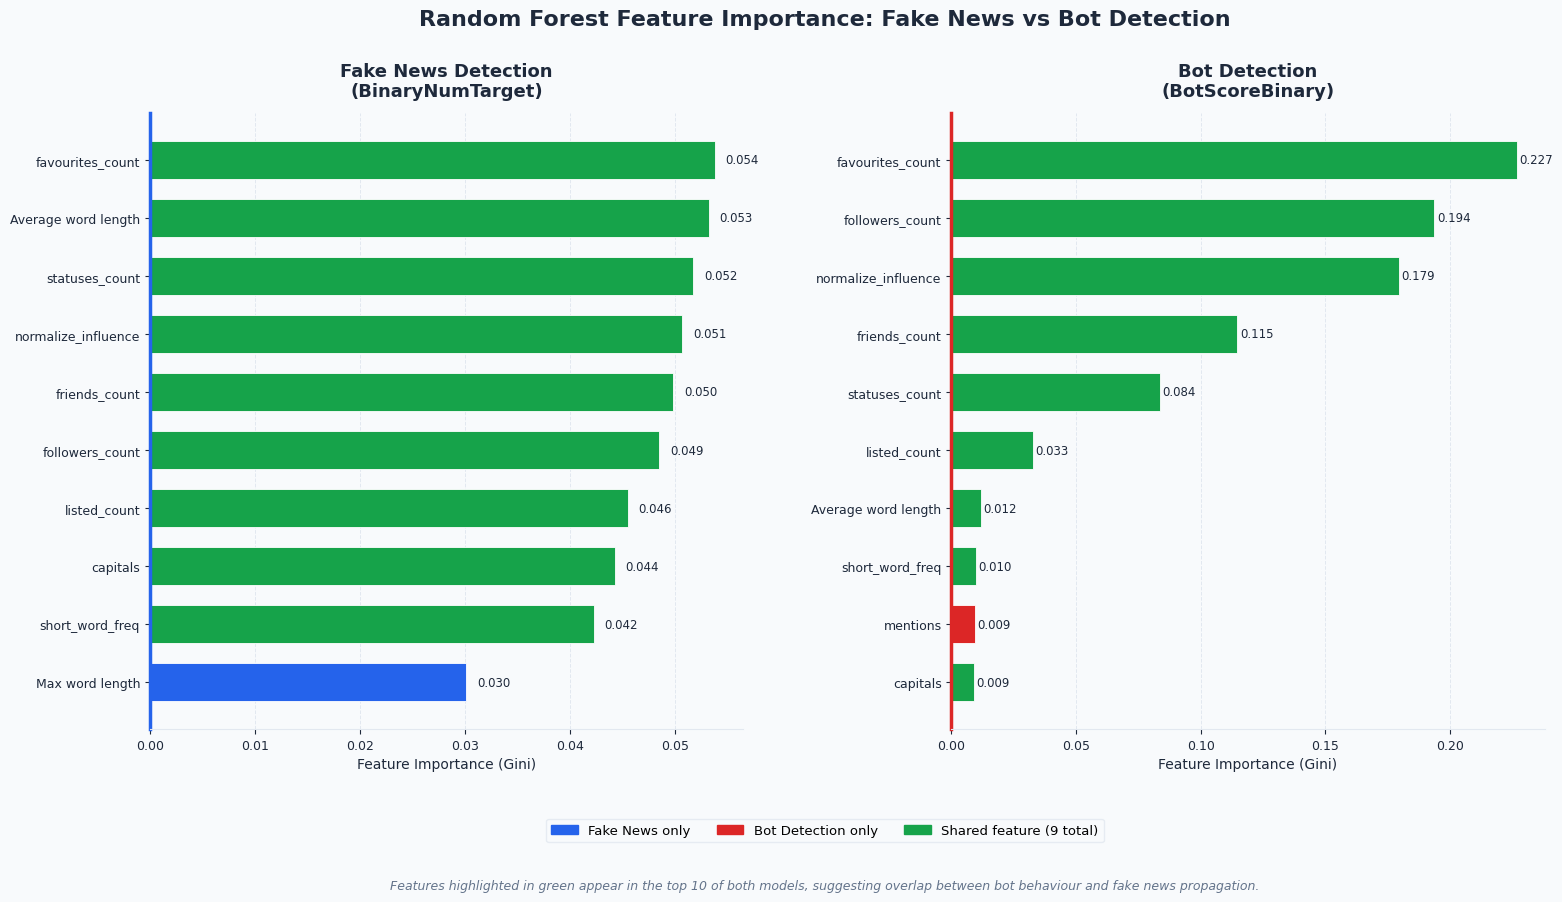

In [30]:
# Random Forest Model to Identify Important Features in Prediction
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import sys

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger('/content/rf.log')

# Loading data in to pandas dataframes and merging in to one d
try:
    logger.info("Loading features from parquet files...")
    lexical  = pd.read_parquet('/content/lexical.parquet')
    metadata = pd.read_parquet('/content/metadata.parquet')
    text     = pd.read_parquet('/content/text.parquet')
    scores   = pd.read_parquet('/content/scores.parquet')

    df = lexical \
        .merge(metadata, on='tweet_ID') \
        .merge(text,     on='tweet_ID') \
        .merge(scores,   on='tweet_ID')
    logger.info(f"Merged dataframe: {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError as e:
    logger.error(f"Parquet file not found: {e} — run the loading cell first")
    sys.exit(1)
except Exception as e:
    logger.error(f"Failed to load parquet files: {e}")
    sys.exit(1)

# Preparing features for analysis by dropping target and irrelevant columns, coercing features to numeric and filling null values with NaN(or 0)
def prepare_features(df, target, exclude_cols):
    """Drop target and irrelevant cols, coerce to numeric, fill NaN"""
    try:
        drop = [c for c in exclude_cols if c in df.columns]
        if target not in df.columns:
            logger.error(f"Target column '{target}' not found")
            sys.exit(1)

        # Drop rows where the target variable is NaN
        initial_rows = df.shape[0]
        df_cleaned = df.dropna(subset=[target]).copy()
        if df_cleaned.shape[0] != initial_rows:
            logger.warning(f"Dropped {initial_rows - df_cleaned.shape[0]} rows due to NaN values in target column '{target}'.")

        X = df_cleaned.drop(columns=drop)
        y = df_cleaned[target]

        for col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce')
        nan_counts = X.isna().sum()
        if nan_counts.any():
            logger.warning(f"NaN values found in features, filling with 0:\n{nan_counts[nan_counts > 0]}")
        X = X.fillna(0)
        return X, y
    except Exception as e:
        logger.error(f"Error preparing features for target '{target}': {e}")
        sys.exit(1)

# Splitting, scaling, training, and evaluating random forest model
def train_rf(X, y, label):
    try:
        if len(X) == 0:
            logger.error(f"[{label}] Dataframe is empty after feature preparation")
            sys.exit(1)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        logger.info(f"[{label}] Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        logger.info(f"[{label}] Training Random Forest...")
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        logger.info(f"[{label}] Training complete")

        y_pred = rf.predict(X_test)
        print(f"\n── {label} Results ──")
        print(classification_report(y_test, y_pred))
        print(confusion_matrix(y_test, y_pred))

        return rf, X.columns.tolist()

    except ValueError as e:
        logger.error(f"[{label}] ValueError: {e}")
        sys.exit(1)
    except Exception as e:
        logger.error(f"[{label}] Unexpected error: {e}")
        sys.exit(1)

# Model 1 - Random Forest for Fake News Detection using BinaryNumTarget
# Sets target as BinaryNumTarget and drops columns to prevent data leakage and irrelevant factors
logger.info("Model 1: Fake News Detection")

X_fn, y_fn = prepare_features(
    df,
    target='BinaryNumTarget',
    exclude_cols=['tweet_ID', 'BinaryNumTarget', 'BotScore', 'BotScoreBinary', 'cred']
)
rf_fn, cols_fn = train_rf(X_fn, y_fn, "Fake News Detection")

try:
    importance_fn = pd.DataFrame({
        'feature'   : cols_fn,
        'importance': rf_fn.feature_importances_
    }).sort_values('importance', ascending=False)
    logger.info(f"Top 10 Fake News features:\n{importance_fn.head(10).to_string()}")
except Exception as e:
    logger.error(f"Error computing fake news feature importance: {e}")
    sys.exit(1)

# Model 2 - Random Forest for Bot Detection using BotScoreBinary
# Sets target as BotScoreBinary and drops columns to prevent data leakage and irrelevant factors
logger.info("Model 2: Bot Detection")

X_bot, y_bot = prepare_features(
    df,
    target='BotScoreBinary',
    exclude_cols=['tweet_ID', 'BotScoreBinary', 'BotScore', 'BinaryNumTarget', 'cred']
)
rf_bot, cols_bot = train_rf(X_bot, y_bot, "Bot Detection")

try:
    importance_bot = pd.DataFrame({
        'feature'   : cols_bot,
        'importance': rf_bot.feature_importances_
    }).sort_values('importance', ascending=False)
    logger.info(f"Top 10 Bot features:\n{importance_bot.head(10).to_string()}")
except Exception as e:
    logger.error(f"Error computing bot feature importance: {e}")
    sys.exit(1)

# Creating visualization to compare both models
try:
    COLOUR_FN     = '#2563EB'
    COLOUR_BOT    = '#DC2626'
    COLOUR_SHARED = '#16A34A'
    BACKGROUND    = '#F8FAFC'
    GRID_COLOUR   = '#E2E8F0'
    TEXT_COLOUR   = '#1E293B'

    shared = set(importance_fn.head(10)['feature']) & set(importance_bot.head(10)['feature'])
    logger.info(f"Shared features in top 5 of both models: {shared}")

    top_fn  = importance_fn.head(10).copy()
    top_bot = importance_bot.head(10).copy()

    colours_fn  = [COLOUR_SHARED if f in shared else COLOUR_FN  for f in top_fn['feature']]
    colours_bot = [COLOUR_SHARED if f in shared else COLOUR_BOT for f in top_bot['feature']]

    fig = plt.figure(figsize=(18, 8), facecolor=BACKGROUND)
    fig.suptitle(
        'Random Forest Feature Importance: Fake News vs Bot Detection',
        fontsize=16, fontweight='bold', color=TEXT_COLOUR, y=1.01
    )

    gs = GridSpec(1, 2, figure=fig, wspace=0.35)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])

    for ax, data, colours, title, accent in [
        (ax1, top_fn,  colours_fn,  'Fake News Detection\n(BinaryNumTarget)', COLOUR_FN),
        (ax2, top_bot, colours_bot, 'Bot Detection\n(BotScoreBinary)',        COLOUR_BOT),
    ]:
        bars = ax.barh(
            data['feature'], data['importance'],
            color=colours, edgecolor='white', linewidth=0.6, height=0.65
        )
        for bar, val in zip(bars, data['importance']):
            ax.text(
                bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha='left',
                fontsize=8.5, color=TEXT_COLOUR
            )
        ax.invert_yaxis()
        ax.set_title(title, fontsize=13, fontweight='bold', color=TEXT_COLOUR, pad=12)
        ax.set_xlabel('Feature Importance (Gini)', fontsize=10, color=TEXT_COLOUR)
        ax.set_facecolor(BACKGROUND)
        ax.tick_params(colors=TEXT_COLOUR, labelsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['left', 'bottom']].set_color(GRID_COLOUR)
        ax.xaxis.grid(True, color=GRID_COLOUR, linestyle='--', linewidth=0.7)
        ax.set_axisbelow(True)
        ax.spines['left'].set_color(accent)
        ax.spines['left'].set_linewidth(2.5)

    legend_patches = [
        mpatches.Patch(color=COLOUR_FN,     label='Fake News only'),
        mpatches.Patch(color=COLOUR_BOT,    label='Bot Detection only'),
        mpatches.Patch(color=COLOUR_SHARED, label=f'Shared feature ({len(shared)} total)'),
    ]
    fig.legend(
        handles=legend_patches, loc='lower center', ncol=3,
        fontsize=9.5, frameon=True, facecolor=BACKGROUND,
        edgecolor=GRID_COLOUR, bbox_to_anchor=(0.5, -0.04)
    )
    fig.text(
        0.5, -0.09,
        'Features highlighted in green appear in the top 10 of both models, '
        'suggesting overlap between bot behaviour and fake news propagation.',
        ha='center', fontsize=9, color='#64748B', style='italic'
    )

    plt.tight_layout()
    plt.savefig('/content/feature_importance_comparison.png', dpi=200,
                bbox_inches='tight', facecolor=BACKGROUND)
    plt.show()
    logger.info("Visualisation saved to /content/featurescomparison.png")

except Exception as e:
    logger.error(f"Error during visualisation: {e}")
    sys.exit(1)

logger.info("Complete")

## Analysis Rationale

We decided to implement a Random Forest given the paper "Towards Accurate Fake News Detection: Evaluating Machine Learning Approaches and Feature Selection
Strategies" buy Mutaz et al.(Linked in Reading Folder) that indicated that implementing random forest results in high accuracy and AUC-ROC scores. Credibility(cred) originally scored highly as a predictive feature in both models, however as it is likely derived from the same underlying calculations used to generate the bot and fake news labels. Thus, the cred feature along with BotScoreBinary, BotScoreBinary and BinaryNumTarget were dropped to ensure each model learned from behaviorial signals only, rather then the target labels themselves. We chose to not exclude the influence score, as we felt it accurately represented the reach of users despite their designation as a bot or human user. Gini impurity was used as the feature importance metric as it measures how much each feature reduces class impurity across all trees, providing a reliable ranking of predictive signals. Additionally, due to a significant class imbalance in the bot detection model — where non-bots substantially outnumbered bots the class_weight='balanced' was applied to prevent the model from defaulting to the majority class.

## Visualization Rationale
The visualization was carefully selected to clearly show the comparison in important features between models. The bar graph was chosen as it provides a method of clear ranking that most viewers are familiar with. Additonally, We chose to highlight and compare the top 10 features for both fake news detection and bot detection, in order to not overwhelm the viewer while still providing accurate information. The overlapping features are also differentiated using different colors and a clear key making it easier for the viewer to understand the similar features of the models.